In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
bytes_col = "flow_size"

In [10]:
df = pd.read_csv("/home/hsd/workspace/trafpy/examples/comparison_generator/final_data/university_load_9.csv")
df.head()

,Unnamed: 0,flow_id,sn,dn,flow_size,event_time,establish,index
0,0,flow_3189,2,1,925.0,0.000000,1,0
1,1,flow_3526,1,2,650.0,0.000091,1,1
2,2,flow_4994,3,0,100.0,0.002353,1,2
3,3,flow_2762,2,0,1375.0,0.002993,1,3
4,4,flow_2972,1,0,1100.0,0.005712,1,4


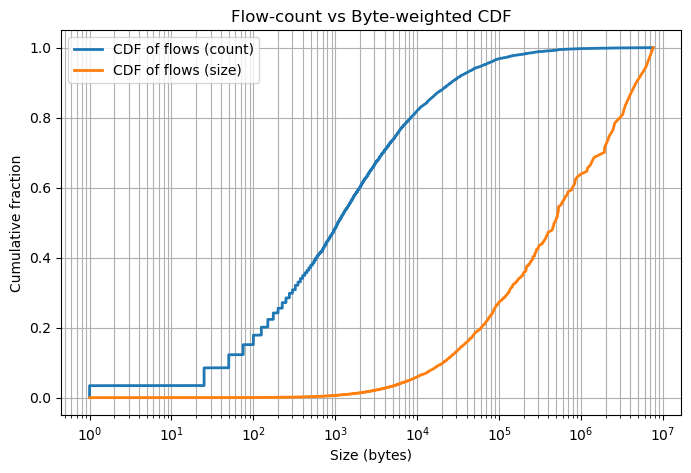

In [11]:
# Sort flow sizes
flow_sizes = np.sort(df["flow_size"].values)
N = len(flow_sizes)

# 1. Flow-count CDF
cdf_flows = np.arange(1, N + 1) / N

# 2. Byte-weighted CDF
cum_bytes = np.cumsum(flow_sizes)
total_bytes = cum_bytes[-1]
cdf_bytes = cum_bytes / total_bytes

plt.figure(figsize=(8, 5))

plt.plot(flow_sizes, cdf_flows, linewidth=2, label="CDF of flows (count)")
plt.plot(flow_sizes, cdf_bytes, linewidth=2, label="CDF of flows (size)")

plt.xscale("log")
plt.xlabel("Size (bytes)")
plt.ylabel("Cumulative fraction")
plt.title("Flow-count vs Byte-weighted CDF")
plt.legend()
plt.grid(True, which="both")
plt.show()

